# DUNE ND-LAr CAF Event Display

This notebook provides an interactive 2D/3D event display for interactions within the **DUNE Near Detector Liquid Argon (ND-LAr)** Common Analysis Format (CAF) flat trees. It draws straight lines between the start and end points of particle hypotheses that came from track objects, and little triangles/cones for particle hypotheses that came from shower objects. Optional truth information can also be plotted/printed.

The heavy lifting (data parsing, truth-matching, and 3D projection rendering) is managed by the external helper module `ndlar_caf_display_helpers.py`.

---

## 0. Prerequisites
To use this event display you will need to install the ndlar-python-package, which we can do here:

In [1]:
!pip install .

Processing /Users/mdk16/Documents/dune-nd-ana/ndlar-caf-display
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ndlar-caf-display: filename=ndlar_caf_display-0.1.1-py3-none-any.whl size=10509 sha256=c952c64a1ed8bba264c23f2d1b5baf7b79d1a41711268c5a7916f508e370475d
  Stored in directory: /Users/mdk16/Library/Caches/pip/wheels/48/29/c6/d7d35ddbb9079f5854c60c4e5020cf33bfdc39699b2db93653
Successfully built ndlar-caf-display
  Attempting uninstall: ndlar-caf-display
    Found existing installation: ndlar-caf-display 0.1.1
    Uninstalling ndlar-caf-display-0.1.1:
      Successfully uninstalled ndlar-caf-display-0.1.1

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


You will also need one or more FLAT ND LAr CAFs.

## 1. Loading and Initialising Data
In the first cells, initialise your environment and point the script to your .root file:

In [2]:
%matplotlib inline
# Import everything explicitly from your helper file
from ndlar_caf_display.helpers import load_interaction_spills, plot_interactions

In [3]:
filedir = '.'
filename = "MicroProdN4p1_NDComplex_FHC.caf.full.spineonly.0002459.CAF.flat.root"
filepath = filedir + '/' + filename

## 2. Choose your reconstruction
The event display will plot straight lines between the start and end position of particle hypotheses. The code was written to accept both DLP and Pandora reconstruction (although at the moment the Pandora part requires debugging).

In [4]:
reco_type = "dlp"
#reco_type = "pandora"
spills = load_interaction_spills(filepath, reco=reco_type)

## 3. Visualisation Modes 🎨

The core visualisation function accepts three distinct configuration modes via the `mode` parameter. Adjust it depending on how much data you want to audit at once.

### Function Parameters Reference 🎛️

`plot_interactions` is configured using the following parameters:

* **`spills`**: The in-memory data object containing the loaded spills extracted from the flat CAF.
* **`spill_index`**: The specific spill or beam slice number you want to view (defaults to `0` for the first spill in the file).
* **`mode`**: Controls how many interactions are plotted at once. Accepted values are:
  * `"single"`: Displays exactly one interaction specified by the `ixn` parameter.
  * `"list"`: Displays only the specific interaction indices passed to `ixn_list`.
  * `"all"`: Displays every single reconstructed interaction found within that spill.
* **`ixn`**: The specific interaction index number to display when running in `mode="single"`.
* **`ixn_list`**: A Python list of interaction index numbers (e.g., `[18, 19, 20]`) to plot simultaneously when running in `mode="list"`.
* **`reco`**: Specifies which reconstruction algorithm data to look up. Set to `"dlp"` for Deep Learning Physics branches or `"pandora"` for Pandora tracking branches.
* **`plot_truth`** chooses whether or not to plot truth information (only possible to be used when plotting less than 20 interactions, otherwise it will turn itself to False). Default is True.
* **`apply_fv_cut`** chooses whether or not to apply a fiducial volume cut (25cm from all sides of active volume). Default is False.
* **`save_dir`** if it is defined, it saves the event displays into an appropriate directory. Default is None.

### Example Mode A: Single Event 
Zooms in on exactly one interaction index to isolate its trajectories from background noise.

Spill: 0 Interaction: 45 
 Reco: [no reco parts] (ov=0.93) 
 Truth: ν̄μ CC DIS [4 π⁻, 1 μ⁺, 3 π⁰, 3 π⁺, 2 n, 4 p]
Successfully saved display to: plots/spill_0_single_ixn45.png


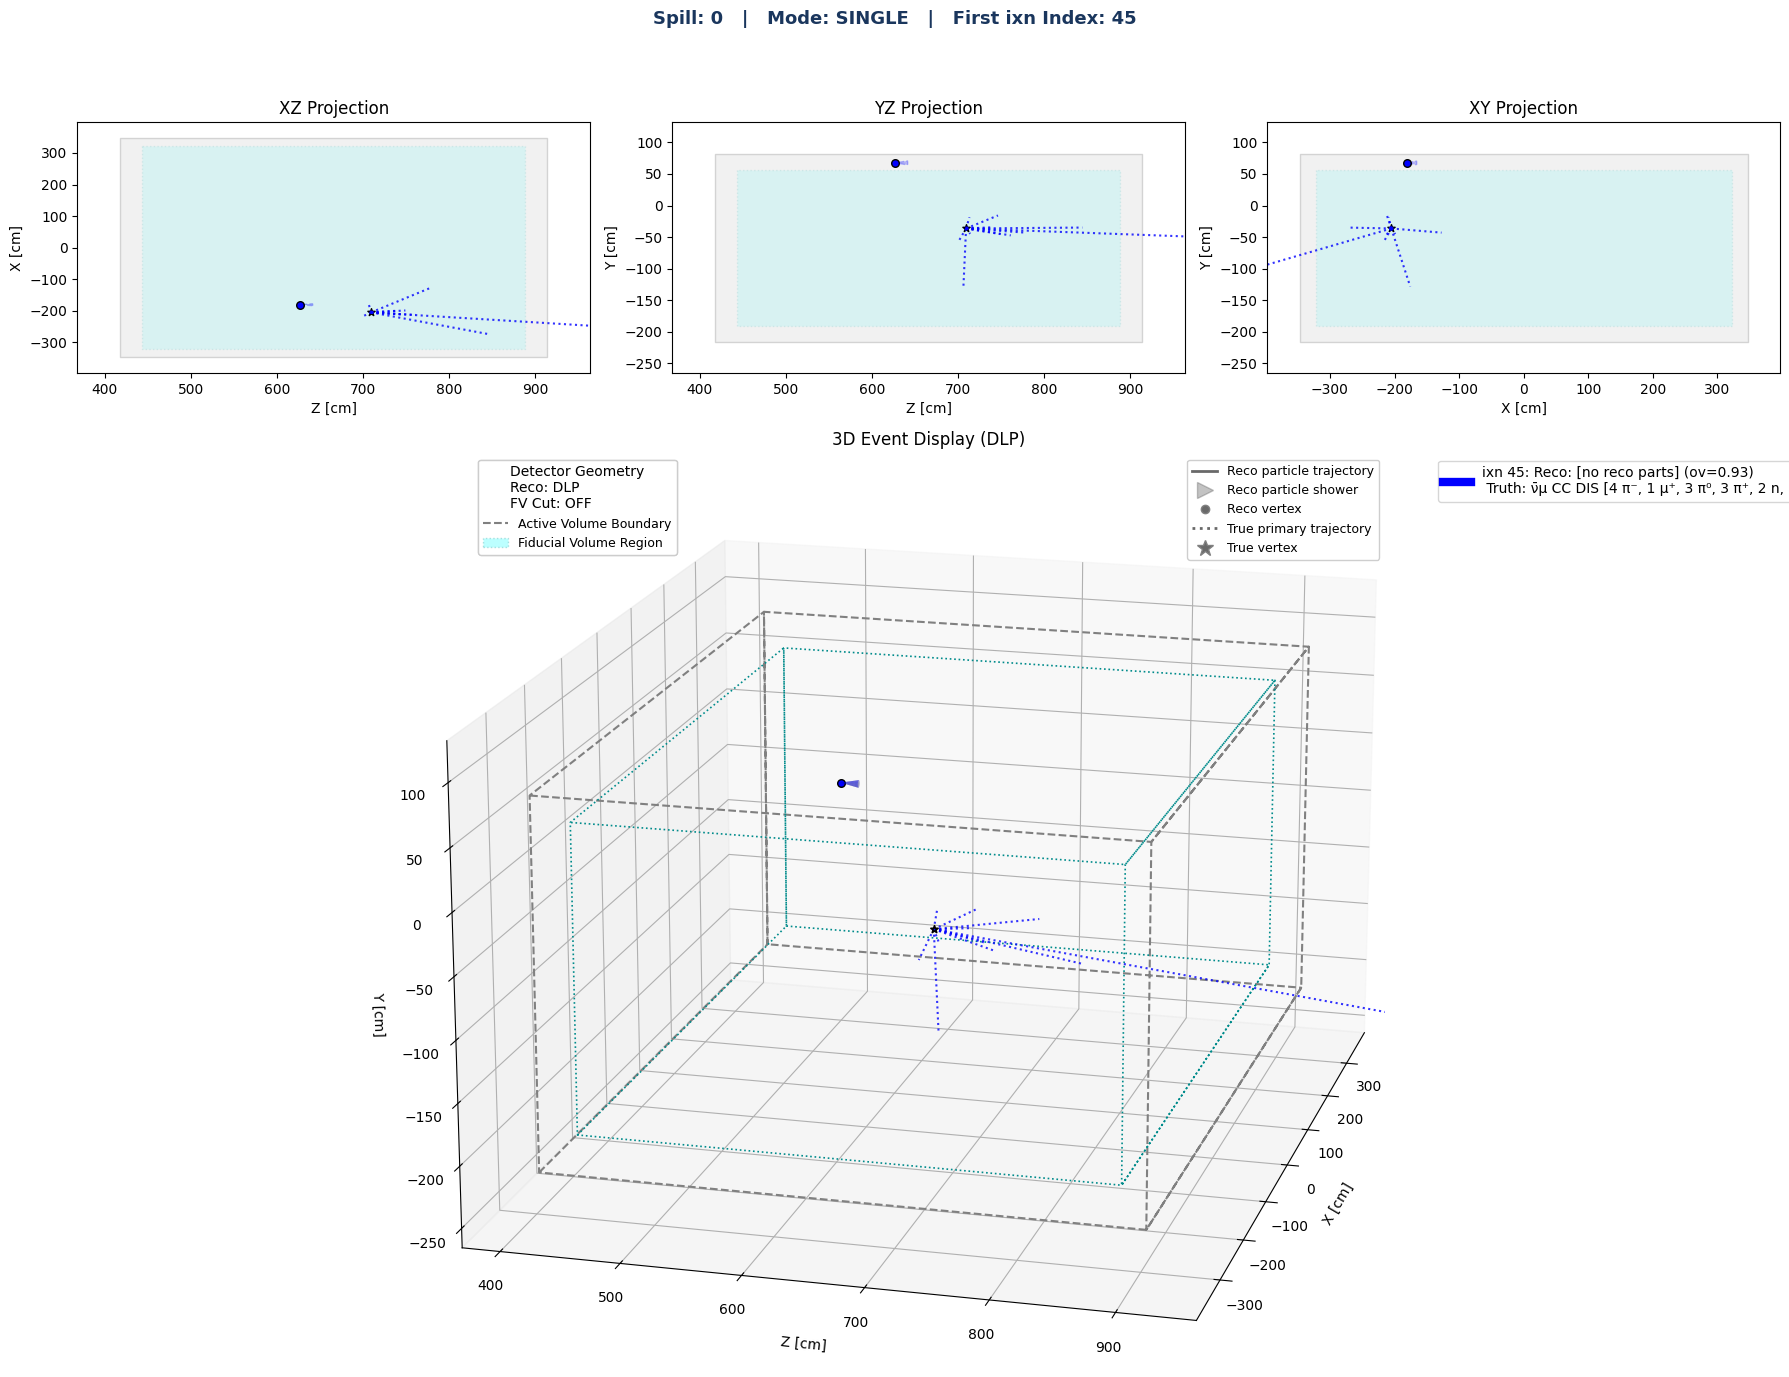

--- Debug info for (DLP) ---
Number of invalid matches:  2 ; out of:  150
Number of possible rock muons:  0 -> []


In [5]:
plot_interactions(spills, spill_index=0, mode="single", ixn=45, reco=reco_type, plot_truth=True, save_dir='plots')

### Example Mode B: Isolated Interaction List 
Focuses exclusively on an array of specific interaction indices. This is perfect for troubleshooting truth interactions that get broken up into multiple reco interactions.

Spill: 0 Interaction: 11 
 Reco: [1 e⁻] (ov=0.39) 
 Truth: νμ CC DIS [1 π⁻, 1 μ⁻, 2 γ, 1 π⁰, 1 π⁺, 3 p]
Spill: 0 Interaction: 13 
 Reco: [1 μ⁻, 1 p] (ov=0.85) 
 Truth: νμ CC QE [1 μ⁻, 1 γ, 1 p]
Spill: 0 Interaction: 14 
 Reco: [1 μ⁻] (ov=0.98) 
 Truth: νμ CC DIS [1 π⁻, 1 μ⁻, 1 π⁰, 2 π⁺, 2 p]
Successfully saved display to: plots/spill_0_list_ixn11.png


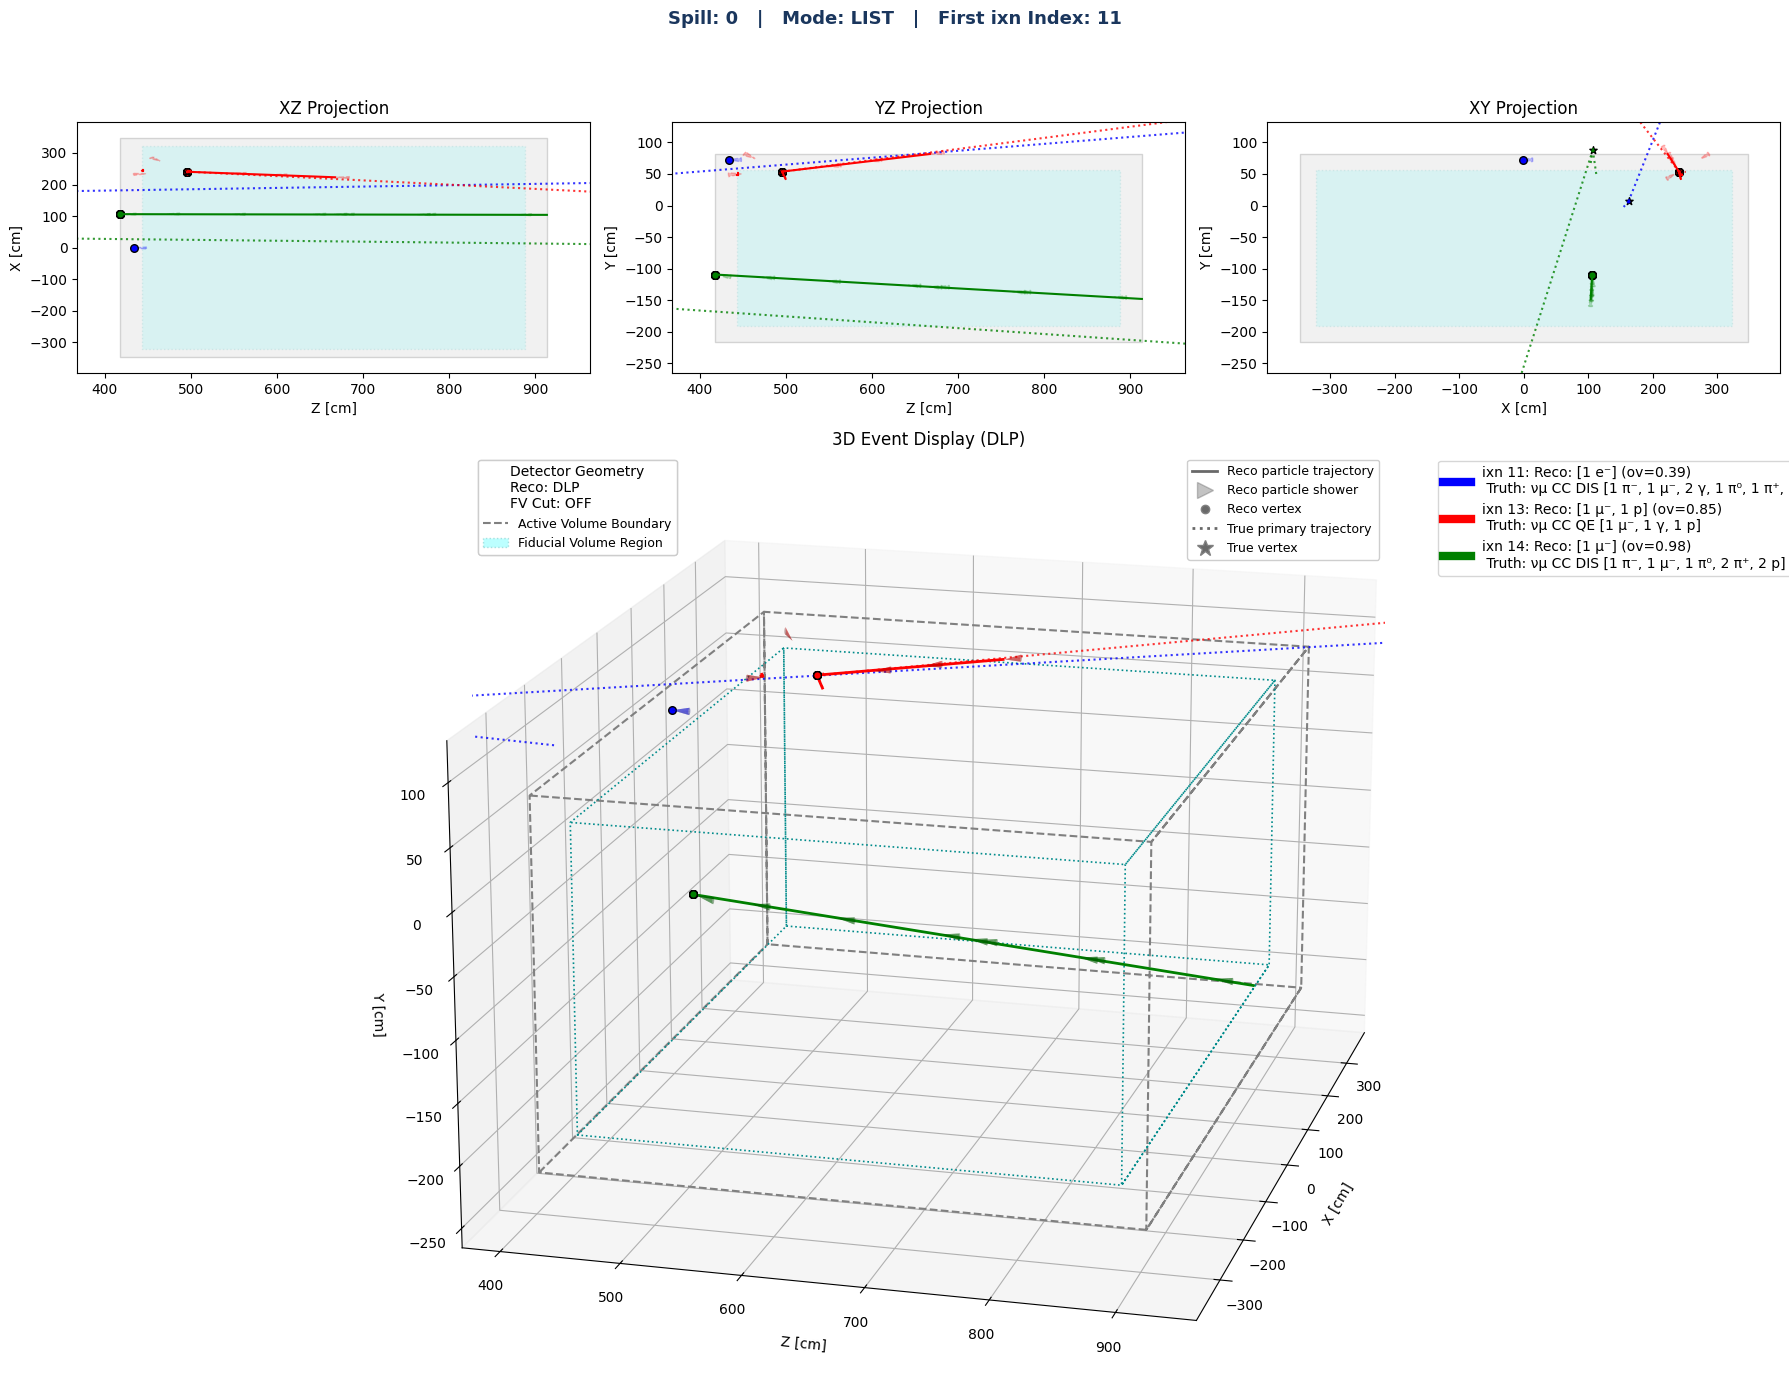

--- Debug info for (DLP) ---
Number of invalid matches:  2 ; out of:  150
Number of possible rock muons:  2 -> [11, 14]


In [6]:
plot_interactions(
    spills, 
    spill_index=0, 
    mode="list", 
    ixn_list=[11, 13, 14],
    reco=reco_type,
    plot_truth=True,
    save_dir='plots')

### Example Mode C: Complete Spill Overview
Renders every single reconstructed interaction found inside the given spill slice. Note: For dense spills, this can look visually cluttered.

FV Cut applied. Kept 68 interactions.
NB: More than 20 interactions, switching plot_truth flag to FALSE
Successfully saved display to: plots/spill_0_all_ixn9.png


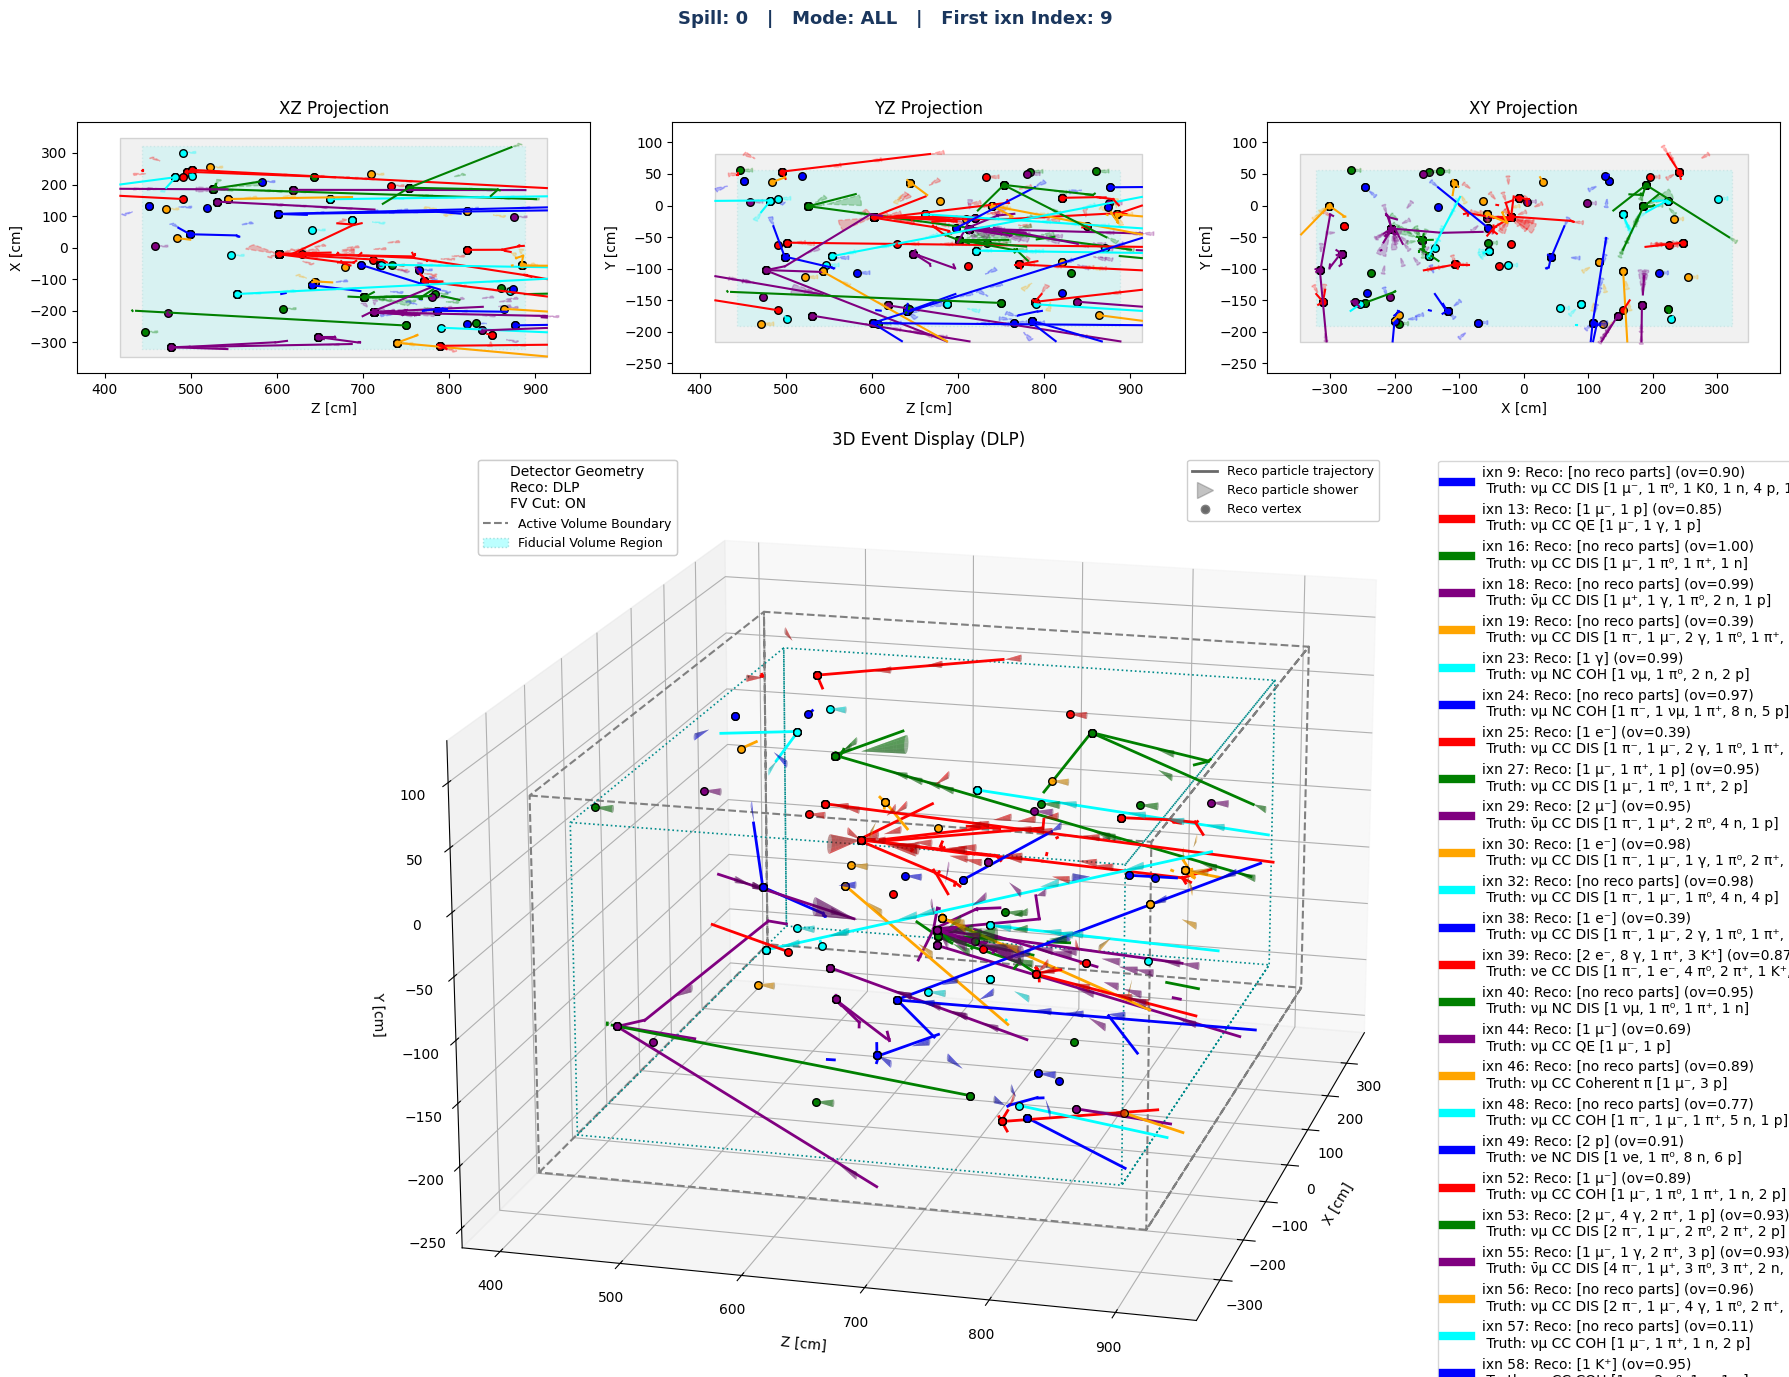

In [7]:
plot_interactions(spills, spill_index=0, mode="all", reco=reco_type, plot_truth=True, apply_fv_cut=True, save_dir='plots')